In [ ]:
# ================================
# 文件名: case6_store_kmeans.py
# 主题: 门店经营类型聚类 - KMeans
# ================================

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

OUTPUT_DIR = "outputs_kmeans_case6"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def generate_store_data(n_samples=1200, random_state=42):
    rng = np.random.default_rng(random_state)

    store_types = rng.choice([0, 1, 2, 3], size=n_samples, p=[0.25, 0.30, 0.20, 0.25])
    rows = []

    for t in store_types:
        if t == 0:
            # 高客流高转化门店
            daily_traffic = np.clip(rng.normal(950, 180), 150, 2000)
            conversion_rate = np.clip(rng.normal(0.30, 0.05), 0.05, 0.80)
            avg_order_value = np.clip(rng.normal(78, 18), 20, 300)
            repeat_customer_ratio = np.clip(rng.normal(0.42, 0.10), 0, 1)
            promo_sales_ratio = np.clip(rng.normal(0.25, 0.08), 0, 1)
            inventory_turnover_days = np.clip(rng.normal(18, 5), 3, 60)
            store_area = np.clip(rng.normal(180, 40), 40, 500)

        elif t == 1:
            # 社区稳定复购门店
            daily_traffic = np.clip(rng.normal(520, 120), 80, 1200)
            conversion_rate = np.clip(rng.normal(0.34, 0.06), 0.05, 0.80)
            avg_order_value = np.clip(rng.normal(58, 12), 15, 200)
            repeat_customer_ratio = np.clip(rng.normal(0.65, 0.10), 0, 1)
            promo_sales_ratio = np.clip(rng.normal(0.18, 0.07), 0, 1)
            inventory_turnover_days = np.clip(rng.normal(15, 4), 3, 60)
            store_area = np.clip(rng.normal(120, 30), 30, 300)

        elif t == 2:
            # 高客单低客流门店
            daily_traffic = np.clip(rng.normal(260, 90), 30, 800)
            conversion_rate = np.clip(rng.normal(0.22, 0.05), 0.03, 0.80)
            avg_order_value = np.clip(rng.normal(138, 35), 20, 500)
            repeat_customer_ratio = np.clip(rng.normal(0.30, 0.10), 0, 1)
            promo_sales_ratio = np.clip(rng.normal(0.12, 0.05), 0, 1)
            inventory_turnover_days = np.clip(rng.normal(28, 7), 5, 90)
            store_area = np.clip(rng.normal(240, 60), 50, 800)

        else:
            # 促销依赖型门店
            daily_traffic = np.clip(rng.normal(700, 160), 100, 1600)
            conversion_rate = np.clip(rng.normal(0.18, 0.04), 0.03, 0.70)
            avg_order_value = np.clip(rng.normal(52, 14), 10, 180)
            repeat_customer_ratio = np.clip(rng.normal(0.25, 0.08), 0, 1)
            promo_sales_ratio = np.clip(rng.normal(0.55, 0.10), 0, 1)
            inventory_turnover_days = np.clip(rng.normal(24, 6), 5, 90)
            store_area = np.clip(rng.normal(160, 45), 30, 500)

        rows.append([
            daily_traffic,
            conversion_rate,
            avg_order_value,
            repeat_customer_ratio,
            promo_sales_ratio,
            inventory_turnover_days,
            store_area
        ])

    return pd.DataFrame(rows, columns=[
        "daily_traffic",
        "conversion_rate",
        "avg_order_value",
        "repeat_customer_ratio",
        "promo_sales_ratio",
        "inventory_turnover_days",
        "store_area"
    ])

# 1. 数据生成
df_store = generate_store_data()

# 2. 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_store)

# 3. 评估不同 K
k_values = range(2, 9)
inertias = []
sil_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# 4. 绘制肘部图
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Store Clustering - Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "store_elbow.png"), dpi=200)
plt.show()

# 5. 绘制轮廓系数图
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), sil_scores, marker="o", color="darkorange")
plt.title("Store Clustering - Silhouette Scores")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "store_silhouette.png"), dpi=200)
plt.show()

# 6. 假设最终选 K=4
best_k = 4
kmeans = KMeans(n_clusters=best_k, init="k-means++", n_init=20, random_state=42)
df_store["cluster"] = kmeans.fit_predict(X_scaled)

# 7. 门店画像
store_profile = df_store.groupby("cluster").mean().round(2)
print("门店聚类画像:")
print(store_profile)

# 8. 可视化：客流 vs 客单价
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_store,
    x="daily_traffic",
    y="avg_order_value",
    hue="cluster",
    palette="Set2",
    alpha=0.7
)
plt.title("Store Clusters: Traffic vs Avg Order Value")
plt.xlabel("Daily Traffic")
plt.ylabel("Average Order Value")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "store_cluster_scatter.png"), dpi=200)
plt.show()

   recency_days  frequency_90d  monetary_90d  avg_basket_size  \
0     30.451085       3.489561     50.000000         1.386430   
1     24.855962      11.795480   1614.669233         2.935937   
2     62.604414       3.089044    490.468620         1.098194   
3      4.974644       2.963765   1085.928130         2.891040   
4      7.890267      13.217742   2616.472260         4.533992   

   coupon_usage_rate  return_rate  app_visit_days_30  
0           0.563244     0.079937           6.997102  
1           0.736790     0.133630          20.400189  
2           0.255486     0.055272           0.000000  
3           0.377655     0.197547           4.923642  
4           0.058006     0.150495          14.591927  
       recency_days  frequency_90d  monetary_90d  avg_basket_size  \
count   3000.000000    3000.000000   3000.000000      3000.000000   
mean      22.503117       7.249251   1699.080098         3.246072   
std       19.036401       4.578728   1420.144650         1.322908   
min

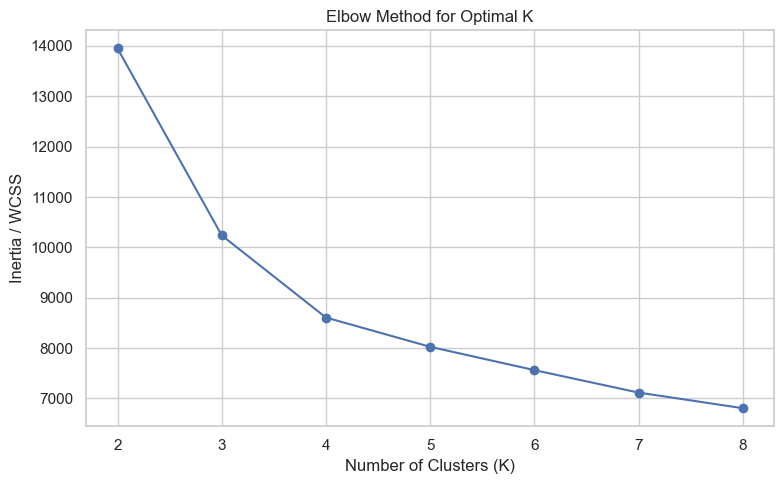

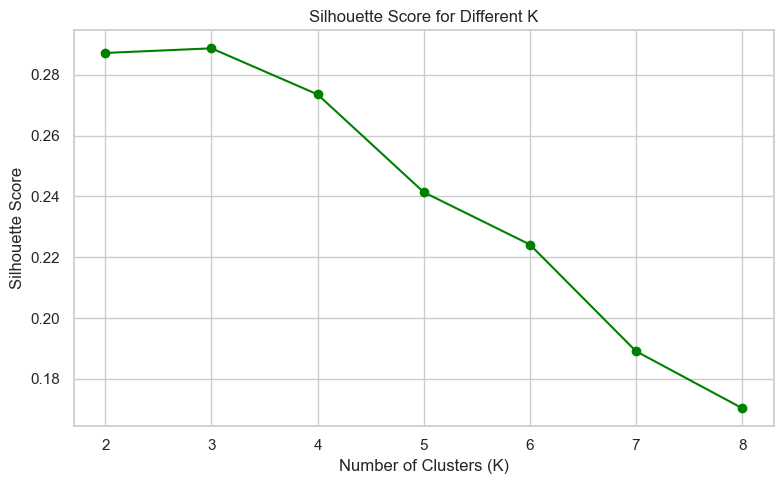


聚类画像:
         recency_days  frequency_90d  monetary_90d  avg_basket_size  \
cluster                                                               
0               15.42           8.08       1566.07             3.27   
1               22.06           4.81        898.27             2.77   
2                8.05          12.24       3572.90             4.63   
3               57.73           2.14        283.71             1.82   

         coupon_usage_rate  return_rate  app_visit_days_30  
cluster                                                     
0                     0.73         0.13              13.90  
1                     0.33         0.09               9.64  
2                     0.25         0.08              18.06  
3                     0.18         0.07               4.02  


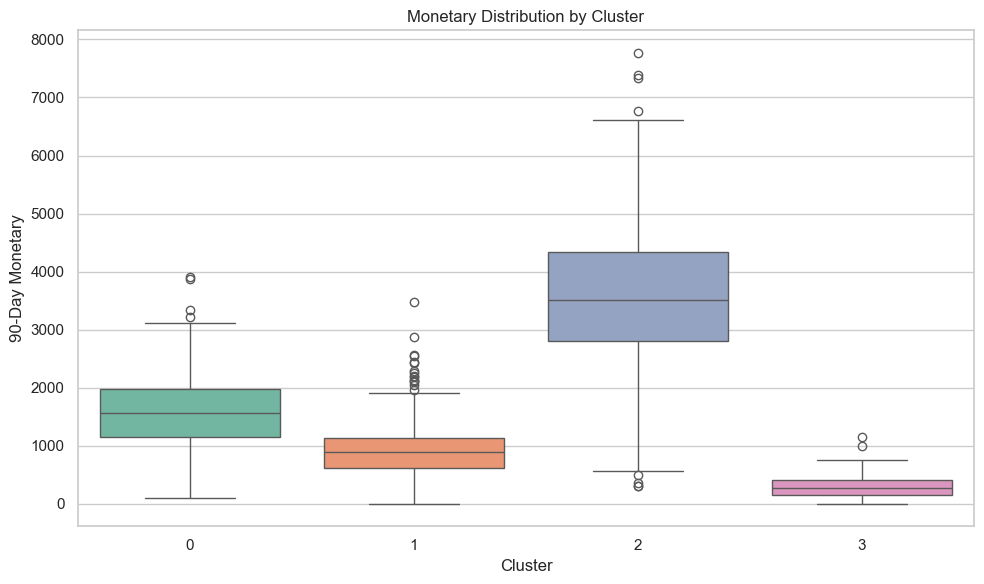

In [1]:
# ================================
# 文件名: case5_ecommerce_kmeans.py
# 主题: 电商用户分层 - KMeans 聚类
# ================================

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

OUTPUT_DIR = "outputs_kmeans_case5"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def generate_ecommerce_user_data(n_samples=3000, random_state=42):
    """
    生成模拟电商用户分层数据
    为了更贴近真实业务，这里人为构造若干潜在人群
    """
    rng = np.random.default_rng(random_state)

    # 4类潜在人群占比
    segment_ids = rng.choice([0, 1, 2, 3], size=n_samples, p=[0.28, 0.24, 0.30, 0.18])

    rows = []

    for seg in segment_ids:
        if seg == 0:
            # 高价值活跃用户
            recency_days = np.clip(rng.normal(8, 4), 1, 30)
            frequency_90d = np.clip(rng.normal(12, 4), 1, 30)
            monetary_90d = np.clip(rng.normal(3500, 1200), 300, 12000)
            avg_basket_size = np.clip(rng.normal(4.5, 1.2), 1, 12)
            coupon_usage_rate = np.clip(rng.normal(0.25, 0.12), 0, 1)
            return_rate = np.clip(rng.normal(0.08, 0.05), 0, 0.6)
            app_visit_days_30 = np.clip(rng.normal(18, 5), 1, 30)

        elif seg == 1:
            # 价格敏感促销型用户
            recency_days = np.clip(rng.normal(15, 6), 1, 45)
            frequency_90d = np.clip(rng.normal(8, 3), 1, 25)
            monetary_90d = np.clip(rng.normal(1600, 600), 100, 6000)
            avg_basket_size = np.clip(rng.normal(3.2, 0.9), 1, 10)
            coupon_usage_rate = np.clip(rng.normal(0.75, 0.10), 0, 1)
            return_rate = np.clip(rng.normal(0.12, 0.06), 0, 0.6)
            app_visit_days_30 = np.clip(rng.normal(14, 4), 1, 30)

        elif seg == 2:
            # 普通稳定用户
            recency_days = np.clip(rng.normal(22, 8), 1, 60)
            frequency_90d = np.clip(rng.normal(5, 2), 1, 18)
            monetary_90d = np.clip(rng.normal(900, 350), 50, 3500)
            avg_basket_size = np.clip(rng.normal(2.8, 0.8), 1, 8)
            coupon_usage_rate = np.clip(rng.normal(0.35, 0.15), 0, 1)
            return_rate = np.clip(rng.normal(0.10, 0.05), 0, 0.6)
            app_visit_days_30 = np.clip(rng.normal(10, 4), 1, 30)

        else:
            # 沉睡/流失边缘用户
            recency_days = np.clip(rng.normal(55, 18), 10, 120)
            frequency_90d = np.clip(rng.normal(2, 1.5), 0, 10)
            monetary_90d = np.clip(rng.normal(280, 180), 0, 1500)
            avg_basket_size = np.clip(rng.normal(1.8, 0.6), 1, 6)
            coupon_usage_rate = np.clip(rng.normal(0.18, 0.10), 0, 1)
            return_rate = np.clip(rng.normal(0.07, 0.05), 0, 0.6)
            app_visit_days_30 = np.clip(rng.normal(4, 3), 0, 20)

        rows.append([
            recency_days,
            frequency_90d,
            monetary_90d,
            avg_basket_size,
            coupon_usage_rate,
            return_rate,
            app_visit_days_30
        ])

    df = pd.DataFrame(rows, columns=[
        "recency_days",
        "frequency_90d",
        "monetary_90d",
        "avg_basket_size",
        "coupon_usage_rate",
        "return_rate",
        "app_visit_days_30"
    ])

    return df

# 1. 数据准备
df = generate_ecommerce_user_data()

print(df.head())
print(df.describe())

# 2. 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 3. 肘部法则
inertias = []
k_values = range(2, 9)

for k in k_values:
    model = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / WCSS")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "elbow_method.png"), dpi=200)
plt.show()

# 4. 轮廓系数
sil_scores = []
for k in k_values:
    model = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42)
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), sil_scores, marker="o", color="green")
plt.title("Silhouette Score for Different K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "silhouette_scores.png"), dpi=200)
plt.show()

# 5. 假设根据评估选择 K=4
best_k = 4
kmeans = KMeans(n_clusters=best_k, init="k-means++", n_init=20, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

df["cluster"] = cluster_labels

# 6. 聚类结果统计
cluster_profile = df.groupby("cluster").mean().round(2)
print("\n聚类画像:")
print(cluster_profile)

# 7. 可视化：不同簇的消费金额分布
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="cluster", y="monetary_90d", palette="Set2")
plt.title("Monetary Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("90-Day Monetary")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cluster_monetary_boxplot.png"), dpi=200)
plt.show()